### This notebook has evalutation of the performance of a trained binary logistic regression

##### following will be used 
     - confusion matrix
     - precision
     - recall

In [48]:
#from previous ones
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

np.random.seed(42)

n_samples = 200
n_features = 2

X = np.random.randn(n_samples, n_features)

# Weaken signal further
w_true = np.array([1.0, -0.8])
b_true = 0.2

# Increase noise (key change)
noise = np.random.normal(0, 2.0, n_samples)

Z = X @ w_true + b_true + noise

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

p = sigmoid(Z)

# Sample labels
y = (np.random.rand(n_samples) < p).astype(int)

# 🔥 Stronger label noise (crucial)
flip_idx = np.random.choice(n_samples, size=int(0.15 * n_samples), replace=False)
y[flip_idx] = 1 - y[flip_idx]
Z_pred = X @ w_true + b_true
p_pred = sigmoid(Z_pred)

threshold = 0.5
y_pred = (p_pred >= threshold).astype(int)

In [49]:
#Confusion matrix 

TP = np.sum((y == 1) & (y_pred == 1))
TN = np.sum((y == 0) & (y_pred == 0))
FP = np.sum((y == 0) & (y_pred == 1))
FN = np.sum((y == 1) & (y_pred == 0))

print("TP:", TP)
print("TN:", TN)
print("FP:", FP)
print("FN:", FN)

TP: 62
TN: 57
FP: 43
FN: 38


In [50]:
#Accuracy
accuracy = (TP + TN) / (TP + TN + FP + FN)
print("Accuracy:", accuracy)

Accuracy: 0.595


In [51]:
#precision 
precision = TP / (TP + FP) if (TP + FP) != 0 else 0
print("Precision:", precision)

Precision: 0.5904761904761905


In [52]:
#recall
recall = TP / (TP + FN) if (TP + FN) != 0 else 0
print("Recall:", recall)

Recall: 0.62


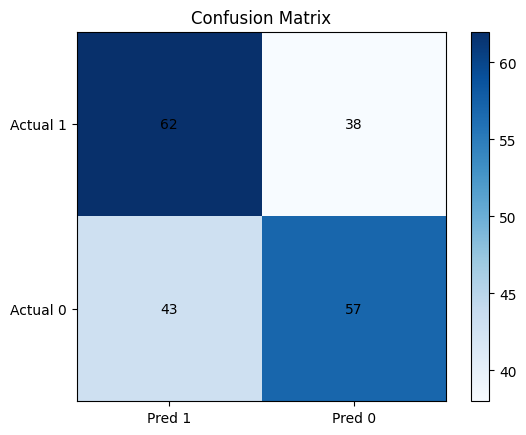

In [53]:
cm = np.array([[TP, FN],
               [FP, TN]])

plt.imshow(cm, cmap='Blues')
plt.colorbar()

plt.xticks([0,1], ["Pred 1", "Pred 0"])
plt.yticks([0,1], ["Actual 1", "Actual 0"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.title("Confusion Matrix")
plt.show()

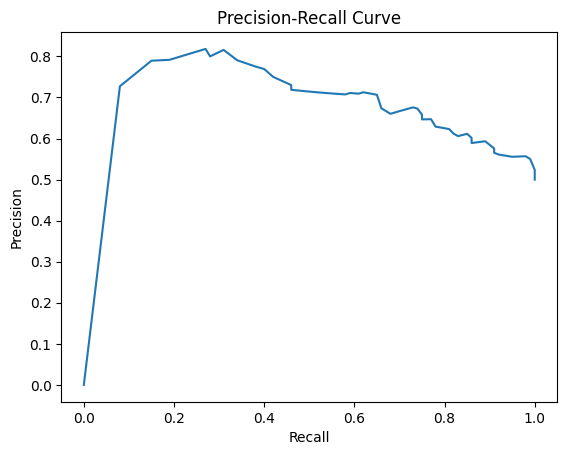

In [54]:
thresholds = np.linspace(0, 1, 50)

precisions = []
recalls = []

for t in thresholds:
    y_pred = (p >= t).astype(int)
    
    TP = np.sum((y == 1) & (y_pred == 1))
    FP = np.sum((y == 0) & (y_pred == 1))
    FN = np.sum((y == 1) & (y_pred == 0))
    
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0
    
    precisions.append(precision)
    recalls.append(recall)

plt.plot(recalls, precisions)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()